In [114]:
using Revise
using NeuralParam
using CairoMakie
using Statistics
using Plots

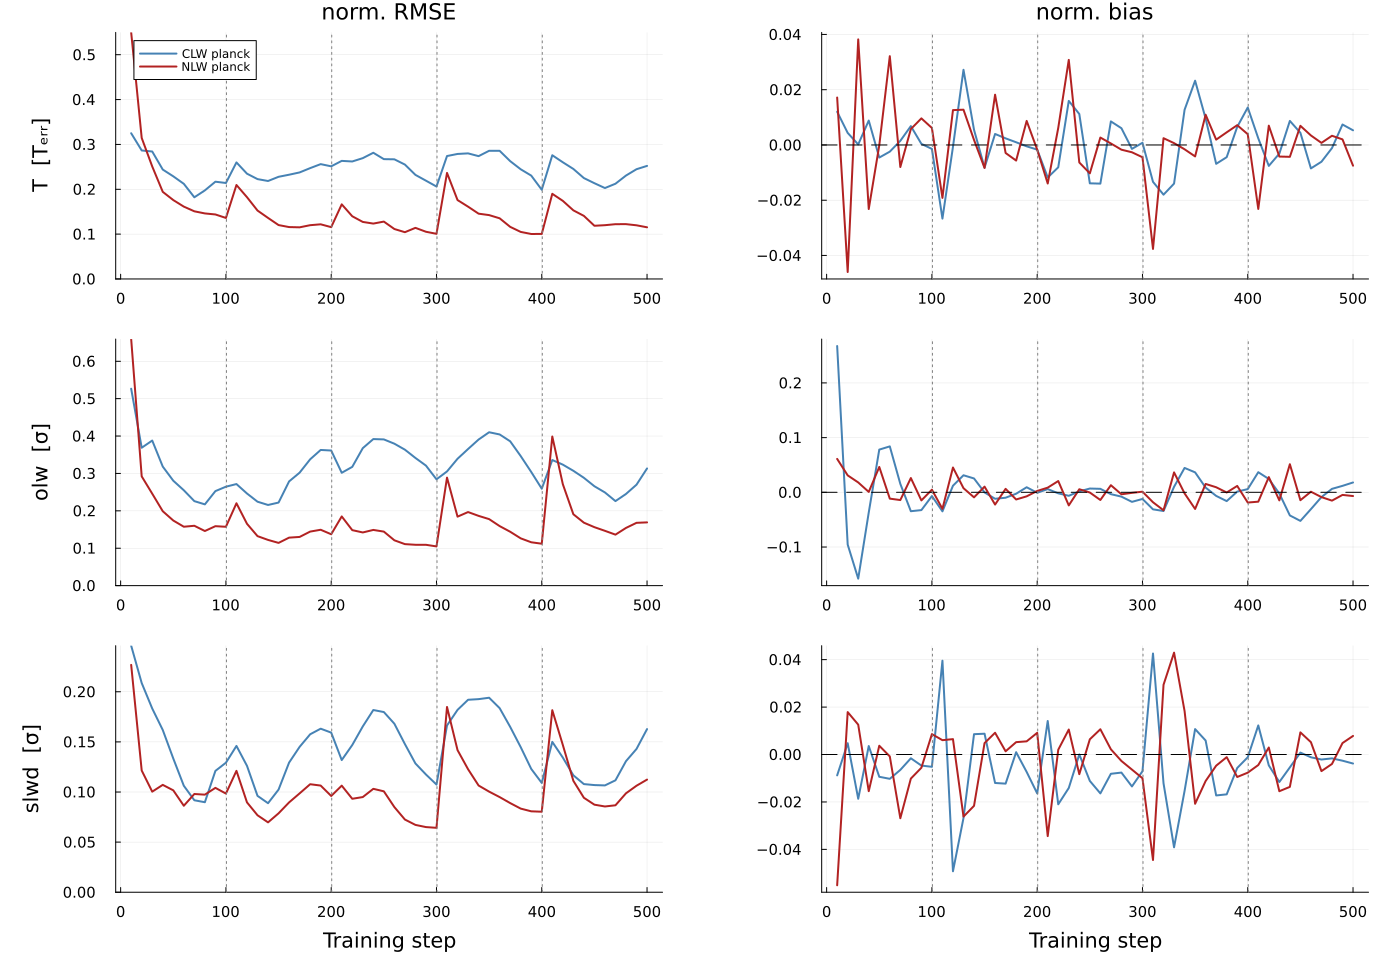

In [115]:
plot_metrics_comp(;
    exp    = ["exp_A_01_CLW_outputForms", "exp_A_02_NLW_outputForms"],
    names  = ["CLW_planck", "NLW_planck"],
    labels = ["CLW planck", "NLW planck"])

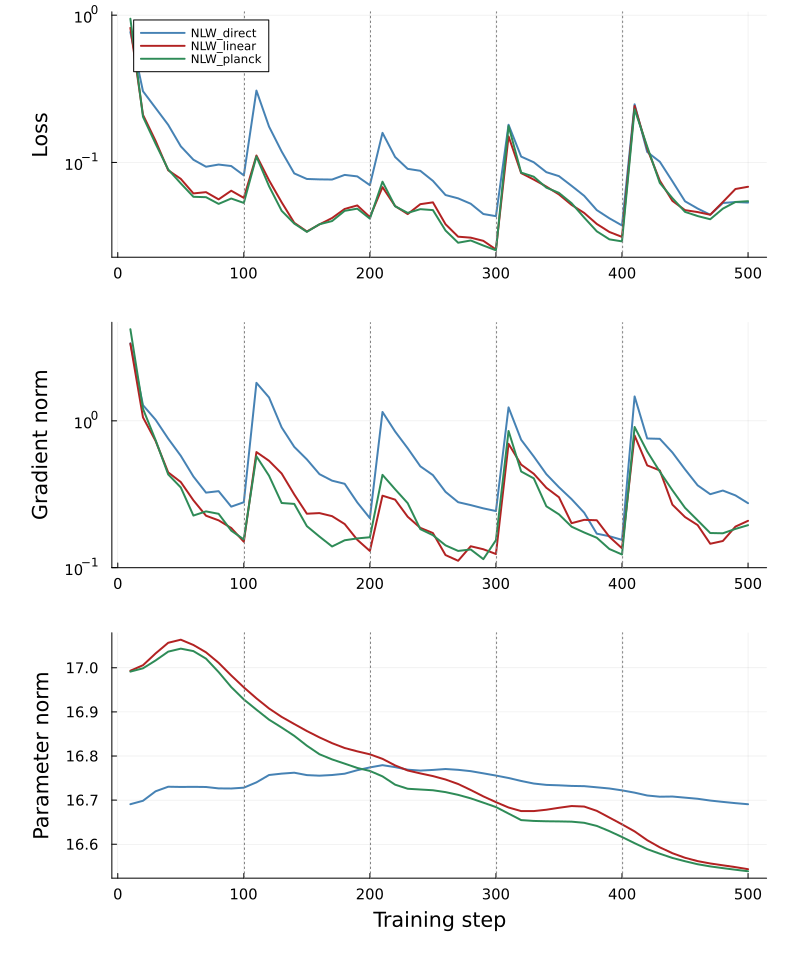

In [116]:
plot_training_comp(; exp = EXP, names = NAMES)

In [117]:
compare_runs(;       exp = EXP, names = NAMES)

Row,scheme,loss,nrmse_T,nrmse_olw,nrmse_slwd,nbias_T,nbias_olw,nbias_slwd,bias_C,gnorm,pnorm
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,NLW_direct,0.0848991,0.15091,0.168597,0.160234,-0.00178953,-0.000488521,-0.00113409,0.111598,0.565509,16.6898
2,NLW_linear,0.0821922,0.134733,0.204535,0.121048,-0.00348919,0.000384918,0.00120143,-0.113493,0.313124,16.5416
3,NLW_planck,0.0774691,0.13756,0.195967,0.111098,-0.00156829,-0.000168147,-0.00144113,0.125661,0.350151,16.5374


In [103]:
EXP = "exp_A_02_NLW_outputForms"
NAMES = ["NLW_direct", "NLW_linear", "NLW_planck"]



3-element Vector{String}:
 "NLW_direct"
 "NLW_linear"
 "NLW_planck"

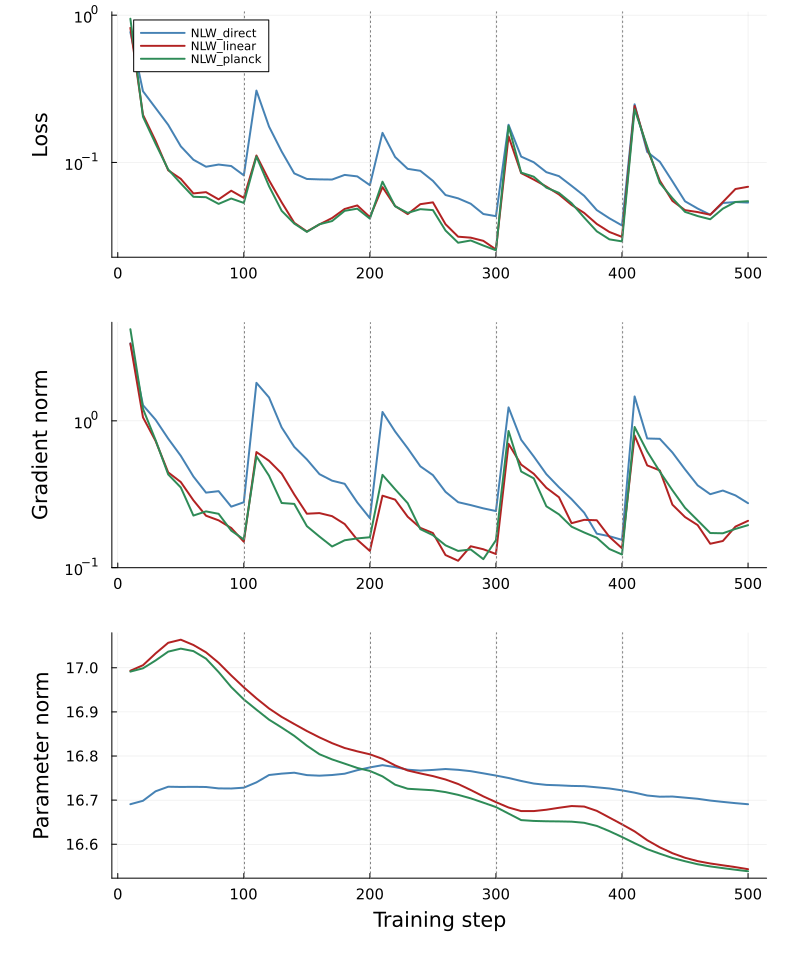

In [113]:
plot_metrics_comp(;  exp = EXP, names = NAMES)

MethodError: MethodError: no method matching _comp_panel(::Vector{DataFrames.DataFrame}, ::Vector{String}, ::Dict{String, Symbol}, ::Symbol; ylabel::String, title::String, xlabel::String, ylims::Tuple{Int64, Float64}, bounds::Vector{Float64}, smooth::Int64, legend::Symbol)

Closest candidates are:
  _comp_panel(::Any, ::Any, ::Any, ::Any; ylabel, bounds, smooth, xlabel, title, yscale, zeroline, legend) got unsupported keyword argument "ylims"
   @ NeuralParam c:\Code\NeuralParam.jl\src\training\plotting.jl:236


Row,scheme,loss,nrmse_T,nrmse_olw,nrmse_slwd,nbias_T,nbias_olw,nbias_slwd,bias_C,gnorm,pnorm
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,NLW_direct,0.0848991,0.15091,0.168597,0.160234,-0.00178953,-0.000488521,-0.00113409,0.111598,0.565509,16.6898
2,NLW_linear,0.0821922,0.134733,0.204535,0.121048,-0.00348919,0.000384918,0.00120143,-0.113493,0.313124,16.5416
3,NLW_planck,0.0774691,0.13756,0.195967,0.111098,-0.00156829,-0.000168147,-0.00144113,0.125661,0.350151,16.5374


In [21]:
SKILL_NAMES = ["OBLW_default_skill", "NLW_direct_default_skill", "NLW_linear_default_skill", "NLW_planck_default_skill"]
STAB_NAMES = replace.(SKILL_NAMES, "skill" => "stab")

skill = collect_rollouts(SKILL_NAMES)
stab = collect_rollouts(STAB_NAMES)

(OBLW_default_stab = (days = 1:180, probes = (:T, :olw, :slwd, :slwu), start_days = [0, 91, 182, 274], scores = (T = (rmse = Float32[0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0;;; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0;;; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0;;; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0;;; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0;;; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0;;; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0;;; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0], bias = Float32[0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0;;; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0;;; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0;;; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; … ; 0

In [22]:
### 1. Sanity: OBLW rolled out against its own reference must be ~0 at every lead day
for p in (:T, :olw, :slwd)
    c = rollout_curve(skill.OBLW_default_skill, p, :rmse)
    println("OBLW self-rmse  $(rpad(p,5)):  day1 = $(c[1])   day31 = $(c[end])")
end


OBLW self-rmse  T    :  day1 = 0.0   day31 = 0.0
OBLW self-rmse  olw  :  day1 = 0.0   day31 = 0.0
OBLW self-rmse  slwd :  day1 = 0.0   day31 = 0.0


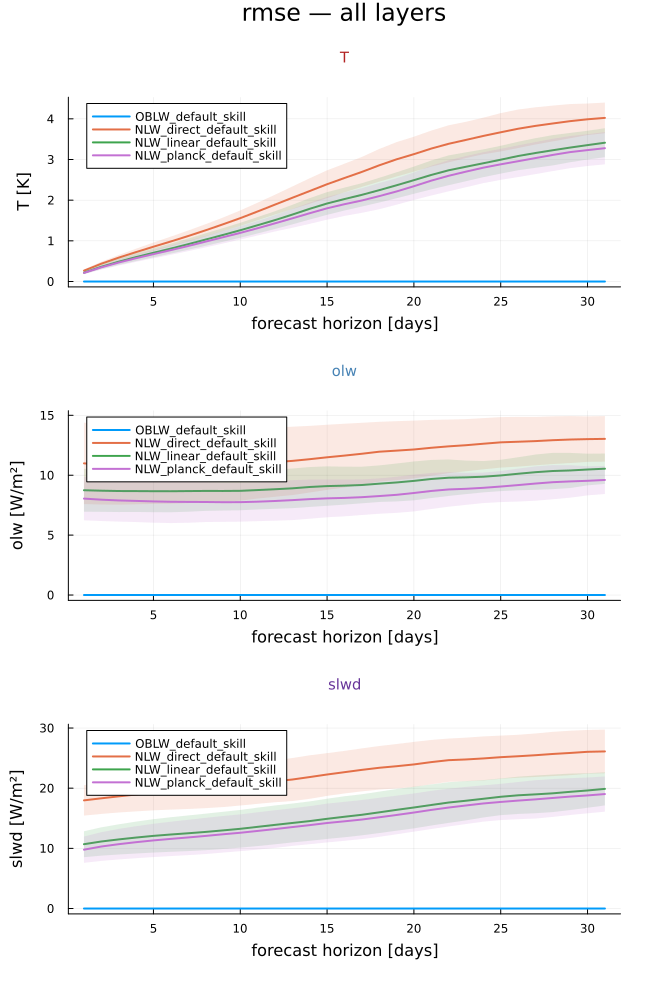

In [23]:
plot_rollout(rollouts = skill, metric = :rmse)

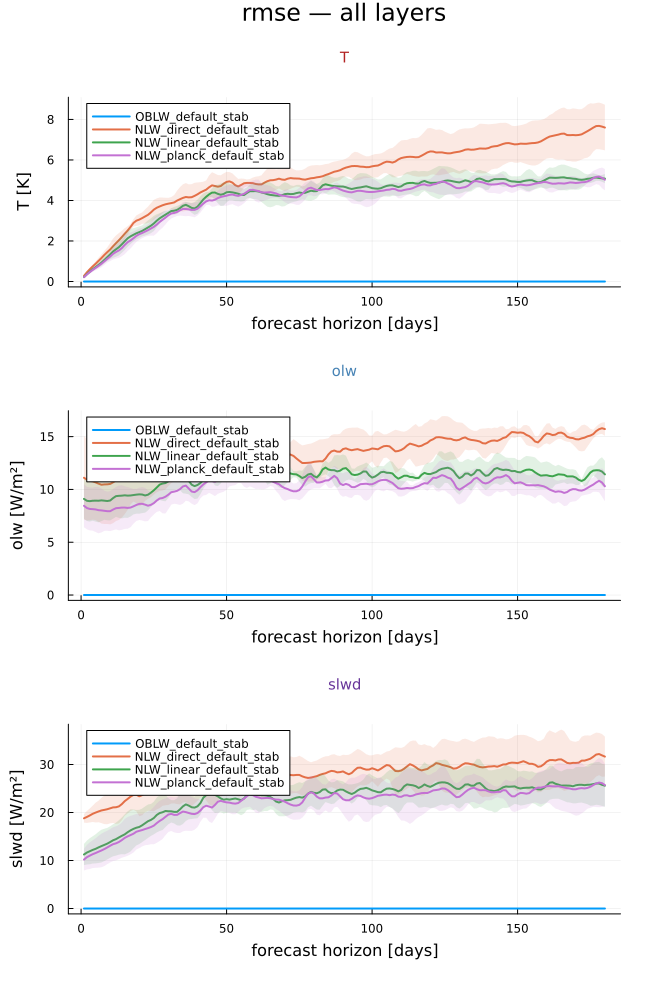

In [24]:
plot_rollout(rollouts = stab, metric = :rmse)

In [10]:
plot_rollout_metrics(;
    rollouts = skill,
    metrics = (:rmse, :bias),
    probes = (:T, :olw, :slwd),
    dir = "C:/Code/NeuralParam.jl/evaluation/plots"
)

┌ Info: Rollout plots stored at C:/Code/NeuralParam.jl/evaluation/plots!
└ @ NeuralParam c:\Code\NeuralParam.jl\src\evaluation\rollout.jl:93


(rmse = Plot{Plots.GRBackend() n=12}, bias = Plot{Plots.GRBackend() n=12})

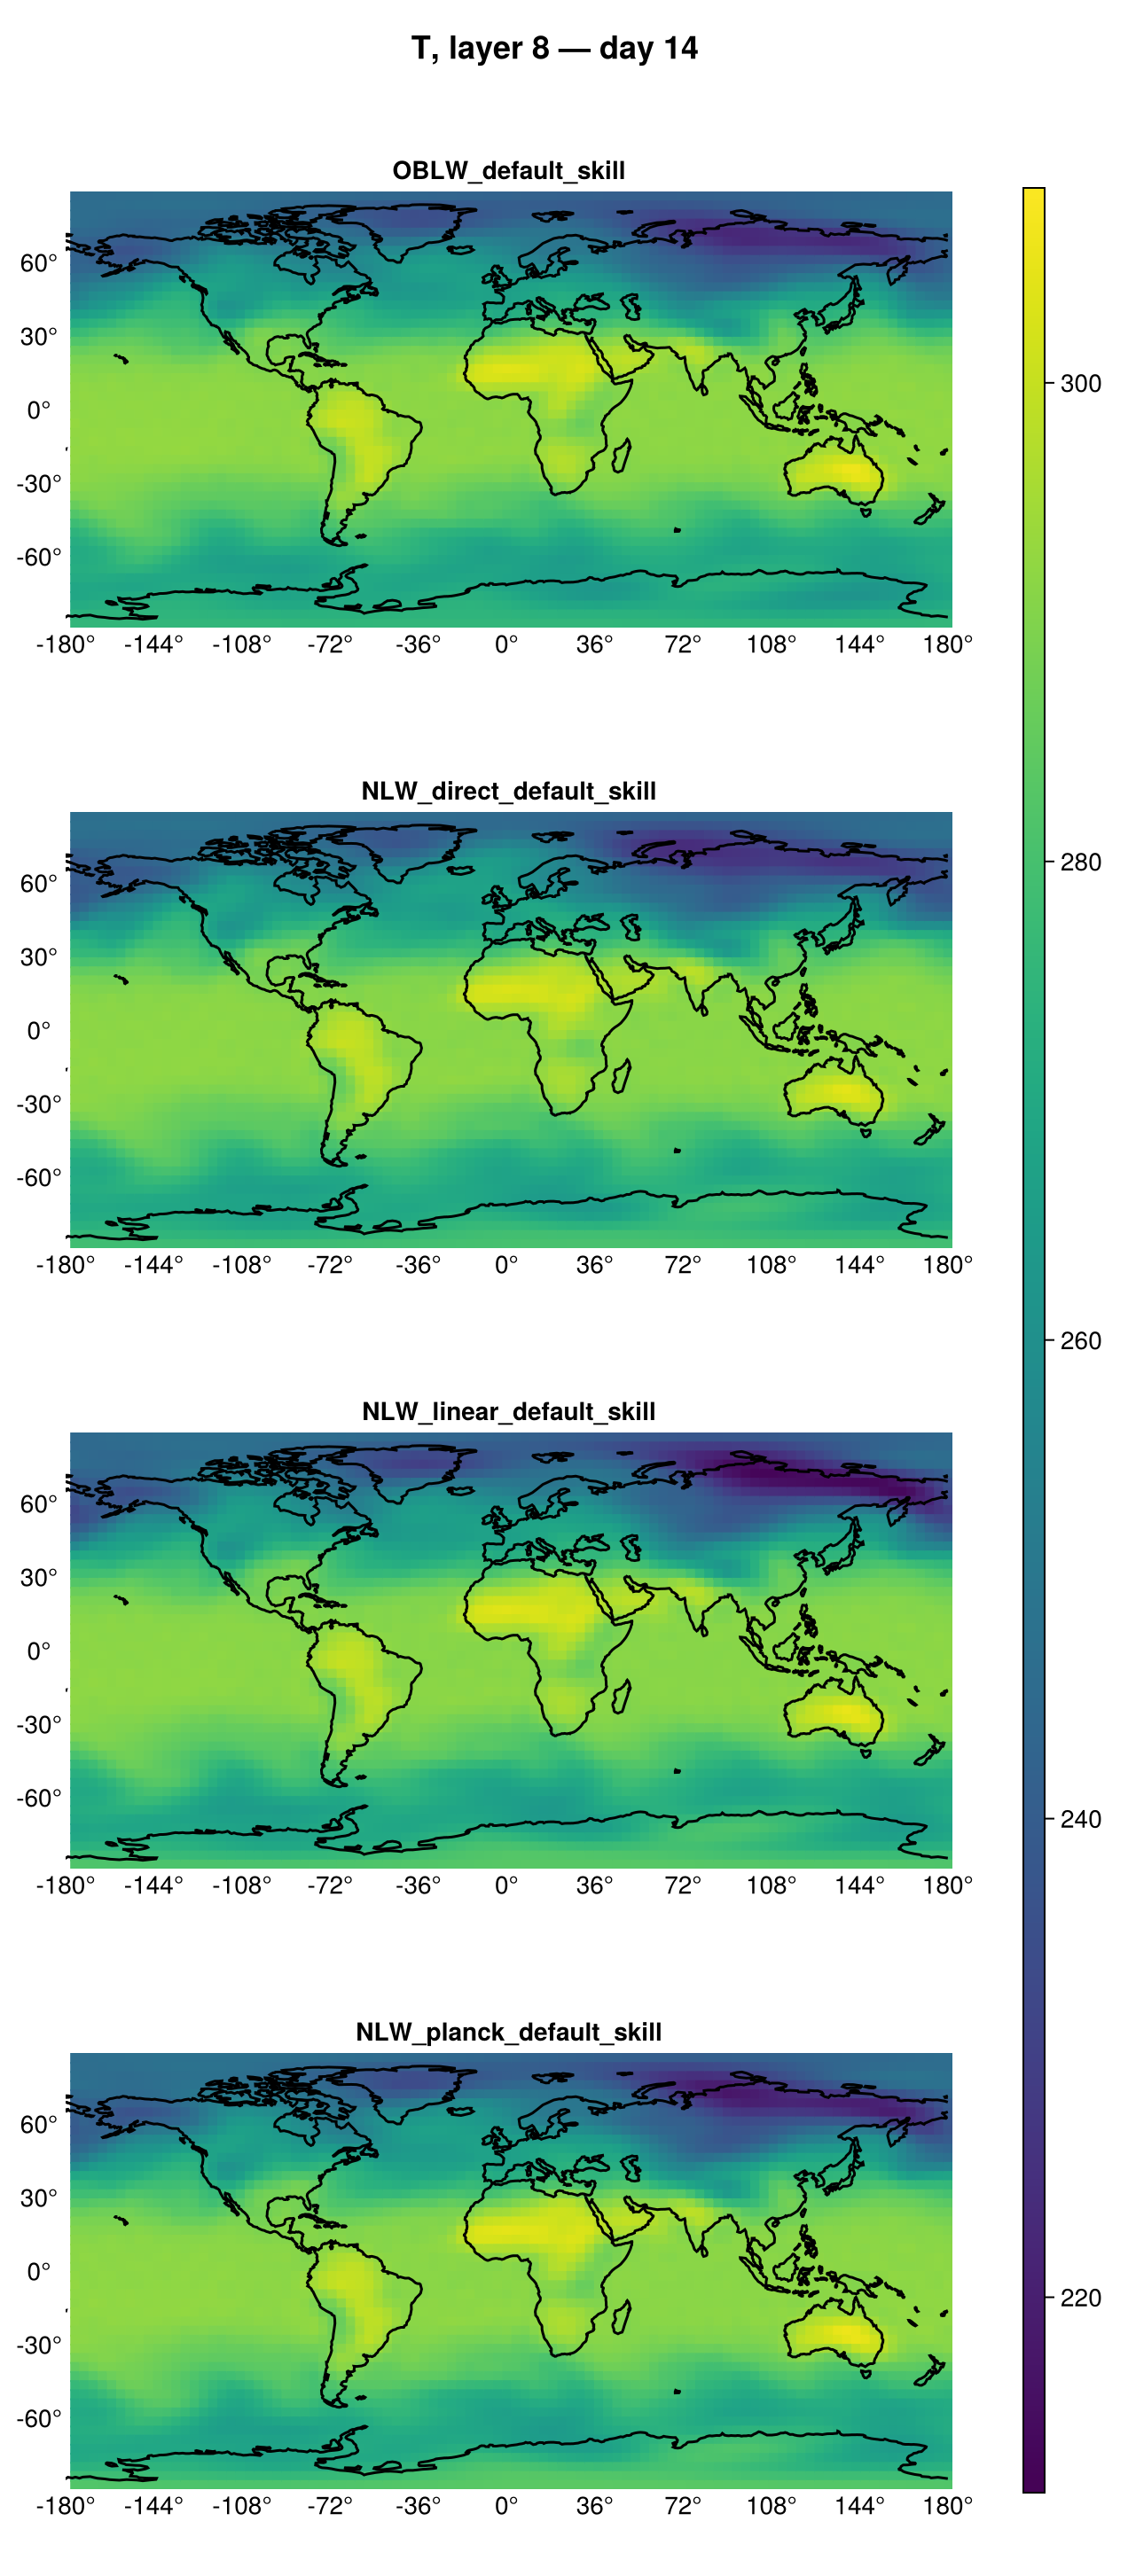

In [33]:
plot_rollout_heatmaps(;
    rollouts = skill,
    var = :T,
    layer = 8,
)[end]

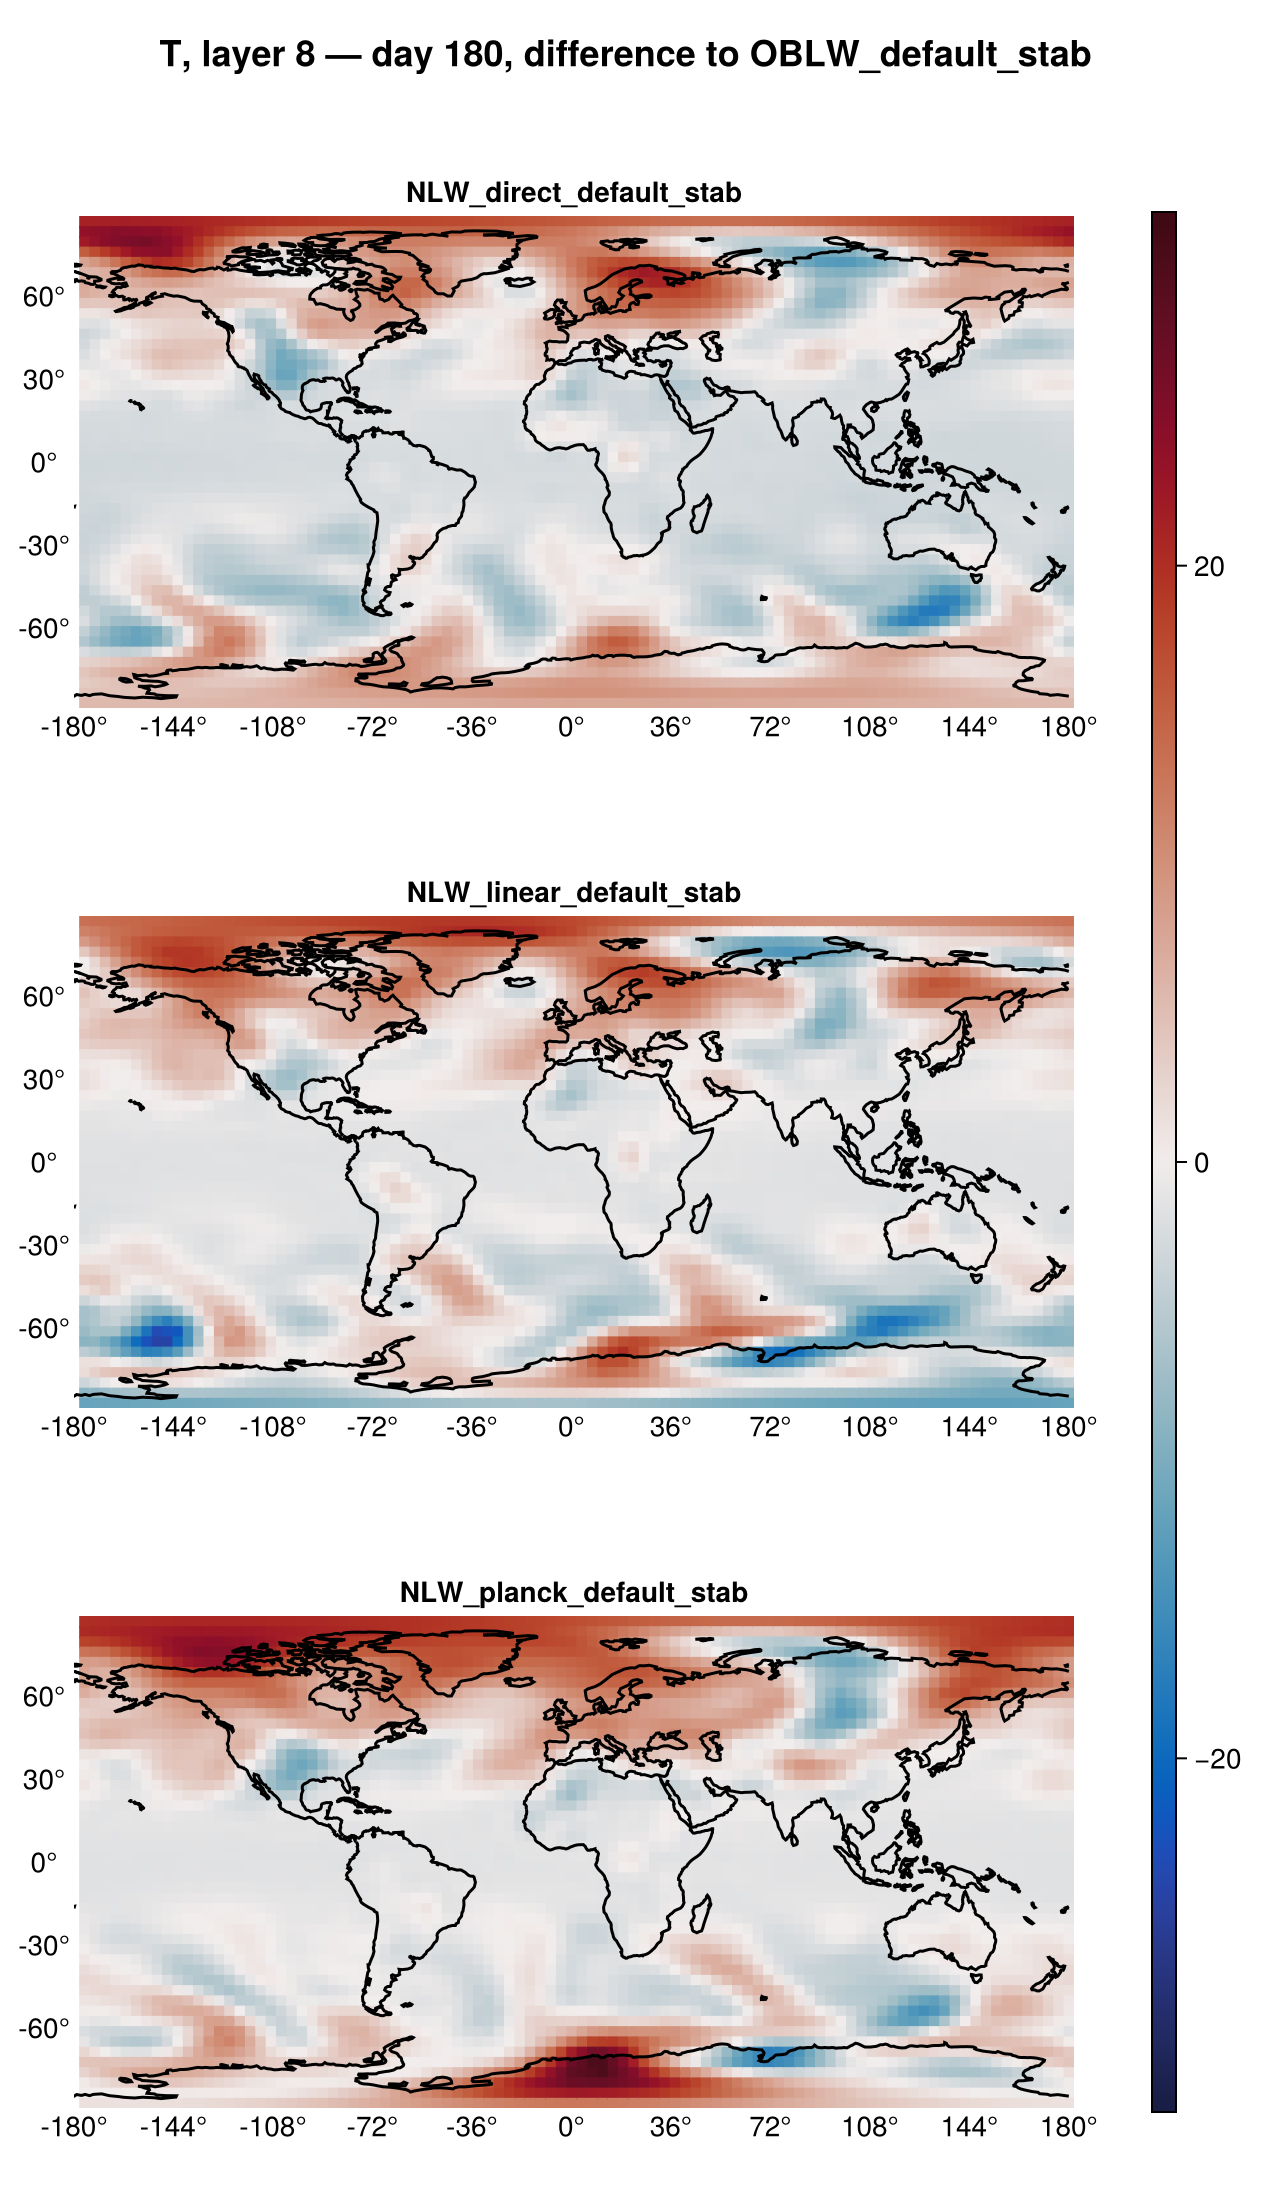

In [31]:
plot_rollout_heatmaps(;
    rollouts = stab,
    var = :T,
    ref = :OBLW_default_stab,
    layer = 8,
)[end]

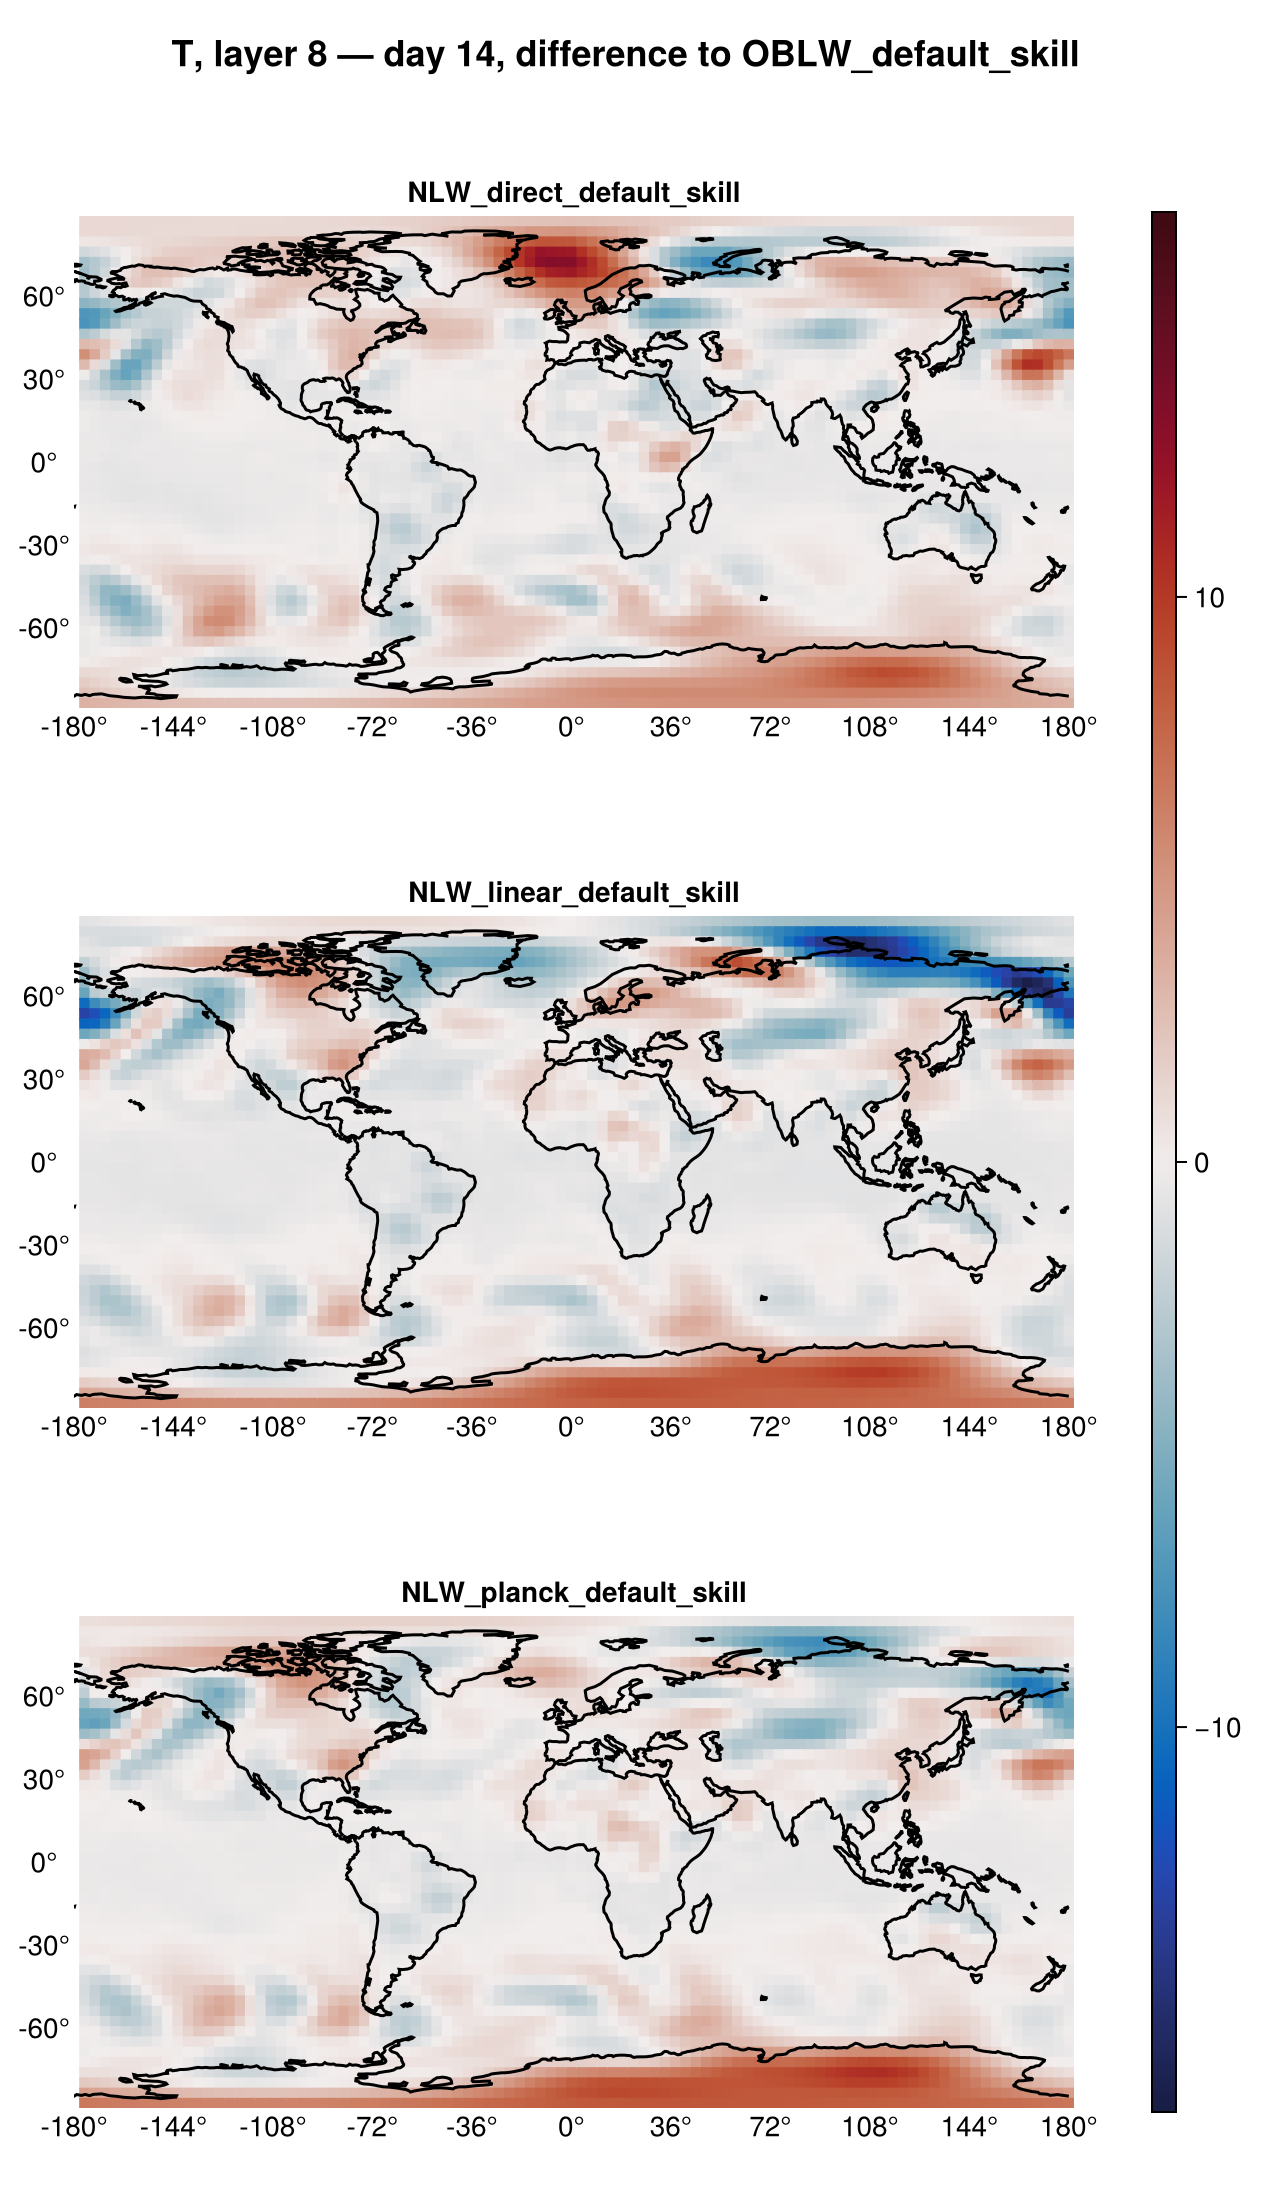

In [32]:
plot_rollout_heatmaps(;
    rollouts = skill,
    var = :T,
    ref = :OBLW_default_skill,
    layer = 8,
)[end]

KeyError: KeyError: key "CLW_planck" not found